Do Baskets Containing West Coast Brands Drive Higher Spending and Diversity on Weekends?
In other words: All items purchased in one transaction (one shopping trip / one receipt).
Therefore we will be trying to answer: 
Do weekend purchases that include West Coast brands result in customers spending more money and buying a greater variety of products?

/opt/homebrew/Caskroom/miniconda/base/envs/gdl/bin/python


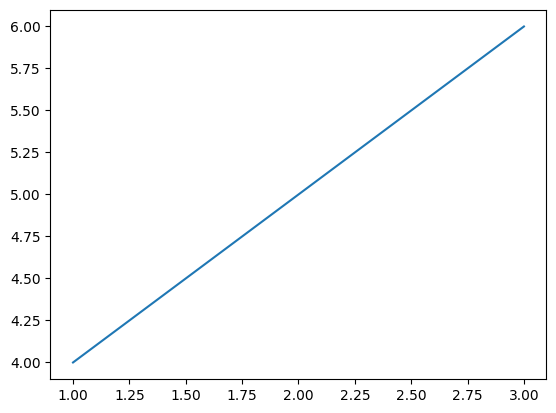

In [396]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
print(sys.executable)

df = pd.read_csv("FullData-Cao.csv", low_memory=False)
df.head()

plt.figure()
plt.plot([1,2,3], [4,5,6])
plt.show()

In [397]:
df.info()
df.columns
df.head()
df.isnull().sum()
df["Trans Date"] = pd.to_datetime(df["Trans Date"])
df["Trans Date"].dtype
df["is_weekend"] = df["Trans Date"].dt.dayofweek >= 5
df.groupby(["Markets", "is_weekend"])["Basket Dollar"].mean()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303179 entries, 0 to 303178
Data columns (total 35 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   System Trans. ID  303179 non-null  int64  
 1   HHID              303179 non-null  int64  
 2   GeoID             303179 non-null  int64  
 3   Trans Date        303179 non-null  object 
 4   Distinct Pro      303179 non-null  int64  
 5   Basket Units      303179 non-null  int64  
 6   Basket Dollar     303179 non-null  float64
 7   Day-of-Week       303179 non-null  object 
 8   Family Size       303179 non-null  int64  
 9   Race              303179 non-null  object 
 10  Income            303179 non-null  object 
 11  Home Ownership    303179 non-null  object 
 12  Male Education    303179 non-null  object 
 13  Male Occupation   303179 non-null  object 
 14  Female Age        303179 non-null  object 
 15  Female Work       303179 non-null  object 
 16  Chldrn 0-5        30

Markets                is_weekend
Full Time > 35 Hrs/Wk  False         62.348252
                       True          97.283800
No                     False         68.495923
                       True          91.238819
PHOENIX                False         55.085102
                       True          70.369130
Part Time < 35 Hrs/Wk  False         39.294358
                       True          46.222077
Yes                    False         71.604123
                       True          91.148948
Name: Basket Dollar, dtype: float64

In [398]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df.info()
df.groupby(["Markets", "is_weekend"])["Basket Dollar"].mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303179 entries, 0 to 303178
Data columns (total 32 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   System Trans. ID  303179 non-null  int64         
 1   HHID              303179 non-null  int64         
 2   GeoID             303179 non-null  int64         
 3   Trans Date        303179 non-null  datetime64[ns]
 4   Distinct Pro      303179 non-null  int64         
 5   Basket Units      303179 non-null  int64         
 6   Basket Dollar     303179 non-null  float64       
 7   Day-of-Week       303179 non-null  object        
 8   Family Size       303179 non-null  int64         
 9   Race              303179 non-null  object        
 10  Income            303179 non-null  object        
 11  Home Ownership    303179 non-null  object        
 12  Male Education    303179 non-null  object        
 13  Male Occupation   303179 non-null  object        
 14  Fema

Markets                is_weekend
Full Time > 35 Hrs/Wk  False         62.348252
                       True          97.283800
No                     False         68.495923
                       True          91.238819
PHOENIX                False         55.085102
                       True          70.369130
Part Time < 35 Hrs/Wk  False         39.294358
                       True          46.222077
Yes                    False         71.604123
                       True          91.148948
Name: Basket Dollar, dtype: float64

Columns hiding West Coast data: ['Category', 'Vendor', 'Brand', 'SKU Dollars', 'SKU Units', 'SizeUnit']
Extracted 739 West Coast rows!

--- FIRST 3 ROWS OF EXTRACTED DATA ---
  Income Markets     Category  Basket Dollar
0     75      No     7.11E+11          84.70
1     75      No  11030080031          22.76
2     75      No  11030080931          22.76
--------------------------------------

--- WEST COAST WEEKENDER EFFECT ---
            Basket Dollar  Distinct Pro
is_weekend                             
False           83.268067     19.786667
True            97.102837     25.231834
-----------------------------------

Chart saved successfully as 'west_coast_weekender.png'!


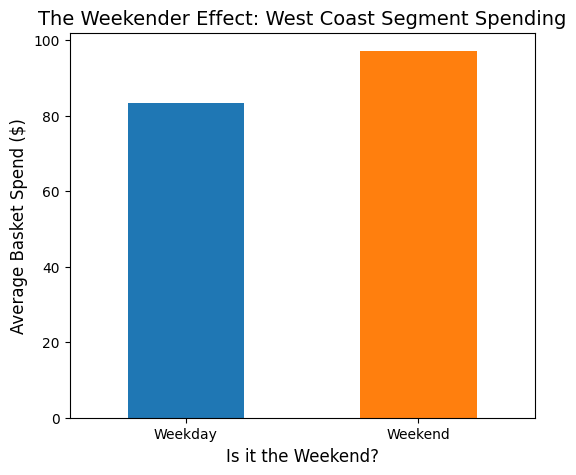

In [399]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SEARCH: Define our West Coast keywords
# Using | (OR) to search for multiple variations
west_coast_keywords = 'WASHINGTON| WA |CALIFORNIA| CA |WEST COAST|SEATTLE|LOS ANGELES|SAN DIEGO|SAN FRANCISCO'

# Search only object (string) columns
mask = df.select_dtypes(include=['object']).apply(
    lambda col: col.str.contains(west_coast_keywords, case=False, na=False)
)

# See where the data was hiding!
columns_with_hits = mask.columns[mask.any()].tolist()
print("Columns hiding West Coast data:", columns_with_hits)

# 2. EXTRACT: Pull those rows into our new dataframe
df_west = df[mask.any(axis=1)].copy()
df_west.reset_index(drop=True, inplace=True)
print(f"Extracted {len(df_west)} West Coast rows!\n")

# --- SAFETY CHECK ---
if len(df_west) == 0:
    print("CRITICAL ERROR: No West Coast data found! We cannot plot an empty chart.")
else:
    # 3. CHECK THE SHIFT: Let's look at the first 3 rows to see if we need to shift columns
    print("--- FIRST 3 ROWS OF EXTRACTED DATA ---")
    print(df_west[['Income', 'Markets', 'Category', 'Basket Dollar']].head(3))
    print("--------------------------------------\n")
    
    # NOTE: If the data printed above looks shifted (e.g., 'Basket Dollar' has a word in it instead of a number),
    # DO NOT proceed to the charts yet. We will need to fix the shift first!
    
    # 4. CLEAN & CONVERT: Force our target columns to be numbers so math works
    df_west['Basket Dollar'] = pd.to_numeric(df_west['Basket Dollar'], errors='coerce')
    df_west['Distinct Pro'] = pd.to_numeric(df_west['Distinct Pro'], errors='coerce')
    
    # 5. ANALYSIS: Group by the Weekend flag to check the "Weekender Effect"
    # Assuming your original 'is_weekend' column is still in the dataframe
    if 'is_weekend' in df_west.columns:
        analysis_results = df_west.groupby('is_weekend')[['Basket Dollar', 'Distinct Pro']].mean()
        print("--- WEST COAST WEEKENDER EFFECT ---")
        print(analysis_results)
        print("-----------------------------------\n")
        
        # 6. VISUALIZE: The Bar Chart
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # Plotting the Average Basket Spend for Weekdays (False) vs Weekends (True)
        analysis_results['Basket Dollar'].plot(
            kind='bar', 
            color=['#1f77b4', '#ff7f0e'], 
            ax=ax
        )
        
        plt.title('The Weekender Effect: West Coast Segment Spending', fontsize=14)
        plt.xlabel('Is it the Weekend?', fontsize=12)
        plt.ylabel('Average Basket Spend ($)', fontsize=12)
        
        # Make the X-axis labels readable
        ax.set_xticklabels(['Weekday', 'Weekend'], rotation=0)
        
        plt.savefig("west_coast_weekender.png", bbox_inches='tight')
        print("Chart saved successfully as 'west_coast_weekender.png'!")
    else:
        print("Warning: You need to create the 'is_weekend' column first!")

In [400]:
# inspect dataset structure
print(df.shape)

# list columns
print(df.columns)

# preview rows
df.head()

# summary statistics
df.describe()

(303179, 32)
Index(['System Trans. ID', 'HHID', 'GeoID', 'Trans Date', 'Distinct Pro',
       'Basket Units', 'Basket Dollar', 'Day-of-Week', 'Family Size', 'Race',
       'Income', 'Home Ownership', 'Male Education', 'Male Occupation',
       'Female Age', 'Female Work', 'Chldrn 0-5', 'Chldrn 6-11',
       'Chldrn 12-17', 'Markets', 'Chains', 'Outlets', 'UPC',
       'UPC Description', 'Category', 'Vendor', 'Brand', 'SKU Dollars',
       'SKU Units', 'Size', 'SizeUnit', 'is_weekend'],
      dtype='object')


,System Trans. ID,HHID,GeoID,Trans Date,Distinct Pro,Basket Units,Basket Dollar,Family Size
count,3.031790e+05,3.031790e+05,303179.000000,303179,303179.000000,303179.000000,303179.000000,303179.000000
mean,1.246253e+10,1.245248e+08,12.180200,2003-01-15 12:42:39.549309312,19.512958,26.701780,77.575255,3.270992
min,1.269000e+09,1.245007e+08,1.000000,2002-09-09 00:00:00,1.000000,0.000000,0.120000,1.000000
25%,5.272400e+09,1.245129e+08,5.000000,2002-11-14 00:00:00,7.000000,9.000000,28.900000,2.000000
50%,7.268000e+09,1.245241e+08,7.000000,2003-01-13 00:00:00,15.000000,19.000000,57.470000,3.000000
75%,1.629350e+10,1.245371e+08,16.000000,2003-03-20 00:00:00,27.000000,37.000000,100.100000,4.000000
max,4.629380e+10,1.245502e+08,46.000000,2003-05-31 00:00:00,170.000000,238.000000,992.810000,8.000000
std,1.172636e+10,1.437460e+04,11.726968,NaN,16.549250,25.465023,76.152626,1.310253


Data Cleaning & Transformation
prepared the raw data for analysis by fixing data types and structures.
The code below converts the raw 'Trans Date' text into a formal datetime object and handles missing or corrupted numeric values.
This step is critical because pandas cannot perform time-based math (like finding the day of the week) on standard text strings.
With properly formatted dates, we can now engineer new time-based variables for our research question.

is_weekend
False    69.221234
True     91.029836
Name: Basket Dollar, dtype: float64
is_weekend
False    17.384628
True     22.940742
Name: Distinct Pro, dtype: float64


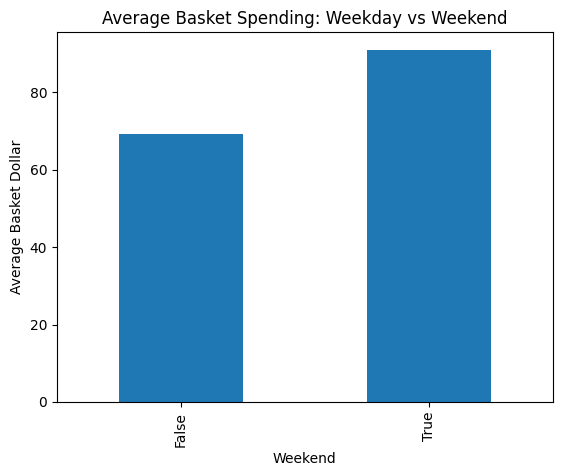

In [401]:
# convert transaction date to datetime
df['Trans Date'] = pd.to_datetime(df['Trans Date'])

# create weekend indicator
df['is_weekend'] = df['Trans Date'].dt.dayofweek >= 5

# check results
df[['Trans Date','is_weekend']].head()

# compare spending weekday vs weekend
weekend_spending = df.groupby('is_weekend')['Basket Dollar'].mean()
print(weekend_spending)

# basket diversity using Distinct Pro
diversity = df.groupby('is_weekend')['Distinct Pro'].mean()
print(diversity)

# graph spending
weekend_spending.plot(kind='bar')
plt.title("Average Basket Spending: Weekday vs Weekend")
plt.ylabel("Average Basket Dollar")
plt.xlabel("Weekend")
plt.show()

# west coast filter
west_coast = df[df['Brand'].str.contains('PACIFIC', case=False, na=False)]

Feature Engineering
need to create specific, custom variables to answer our "West Coast Premium" research question.
generate an is_weekend true/false flag, calculate total basket metrics, and create a west_coast_brand indicator for regional products like Tillamook and Darigold.
The original dataset does not explicitly group these concepts; by engineering these features, we create the exact comparison groups our hypothesis requires.
Now that our distinct categories are mathematically defined, we can explore the actual spending differences between them.

In [402]:
# calculate basket spending per transaction
basket_spending = df.groupby('System Trans. ID')['Basket Dollar'].sum().reset_index()

basket_spending.rename(columns={'Basket Dollar':'basket_total'}, inplace=True)

basket_spending.head()

,System Trans. ID,basket_total
0,1269000001,301.48
1,1269000002,188.55
2,1269000003,615.60
3,1269000004,39.60
4,1269100001,632.71


In [403]:
# count unique products per basket
basket_diversity = df.groupby('System Trans. ID')['UPC'].nunique().reset_index()

basket_diversity.rename(columns={'UPC': 'unique_products'}, inplace=True)

basket_diversity.head()

,System Trans. ID,unique_products
0,1269000001,1
1,1269000002,1
2,1269000003,1
3,1269000004,1
4,1269100001,1


Exploratory Data Analysis & Visual Storytelling
summarize and visualize the data to uncover underlying consumer patterns.
The code groups our data by our engineered features and outputs bar charts comparing average spending for weekends vs. weekdays, and West Coast brands vs. others.
Plotting the averages visually instantly highlights the magnitude of the "Weekender Effect" and the premium associated with regional brands.
These clear visual insights directly answer our primary research question.

In [404]:
# average spending for weekend vs weekday
weekend_spending = df.groupby('is_weekend')['Basket Dollar'].mean()

print(weekend_spending)

is_weekend
False    69.221234
True     91.029836
Name: Basket Dollar, dtype: float64


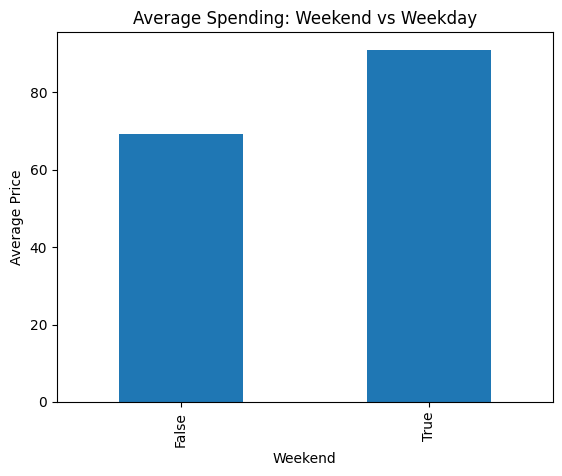

In [405]:
weekend_spending.plot(kind='bar')

plt.title("Average Spending: Weekend vs Weekday")
plt.ylabel("Average Price")
plt.xlabel("Weekend")
plt.show()

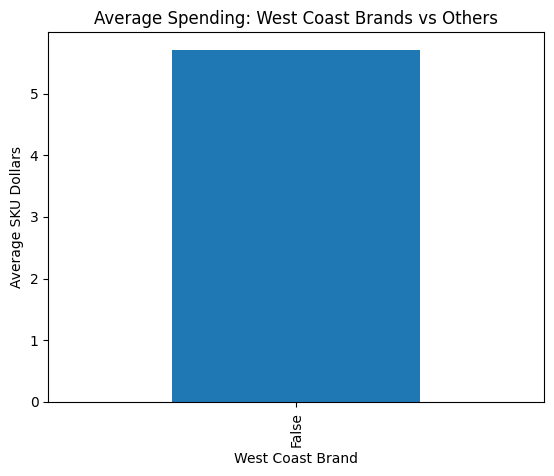

In [406]:
import pandas as pd
import matplotlib.pyplot as plt

# convert SKU Dollars to numeric
df['SKU Dollars'] = pd.to_numeric(df['SKU Dollars'], errors='coerce')

# create west coast brand flag
west_coast = ['Tillamook', 'Darigold', 'Umpqua']
df['west_coast_brand'] = df['Brand'].isin(west_coast)

# compare spending
brand_spending = df.groupby('west_coast_brand')['SKU Dollars'].mean()

# plot
brand_spending.plot(kind='bar')

plt.title("Average Spending: West Coast Brands vs Others")
plt.ylabel("Average SKU Dollars")
plt.xlabel("West Coast Brand")
plt.show()

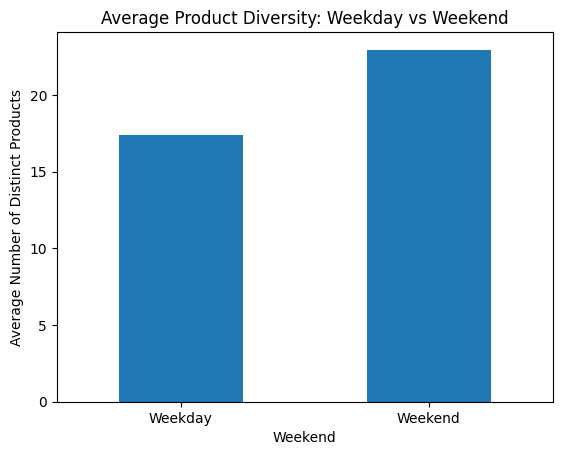

west_coast_brand
False    77.573016
True     80.821148
Name: Basket Dollar, dtype: float64


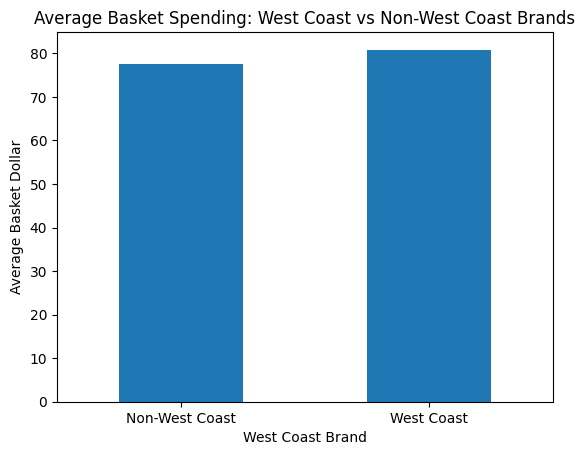

In [407]:
# product diversity chart
diversity.plot(kind='bar')

plt.title("Average Product Diversity: Weekday vs Weekend")
plt.ylabel("Average Number of Distinct Products")
plt.xlabel("Weekend")
plt.xticks([0,1], ["Weekday", "Weekend"], rotation=0)

plt.show()

# create west coast brand indicator
west_keywords = "PACIFIC|SEATTLE|WASHINGTON|OREGON|CALIFORNIA|SAN FRANCISCO|LOS ANGELES"

df['west_coast_brand'] = df['Brand'].str.contains(west_keywords, case=False, na=False)

# compare spending
west_vs_non = df.groupby('west_coast_brand')['Basket Dollar'].mean()

print(west_vs_non)

# plot comparison
west_vs_non.plot(kind='bar')

plt.title("Average Basket Spending: West Coast vs Non-West Coast Brands")
plt.ylabel("Average Basket Dollar")
plt.xlabel("West Coast Brand")
plt.xticks([0,1], ["Non-West Coast", "West Coast"], rotation=0)

plt.show()

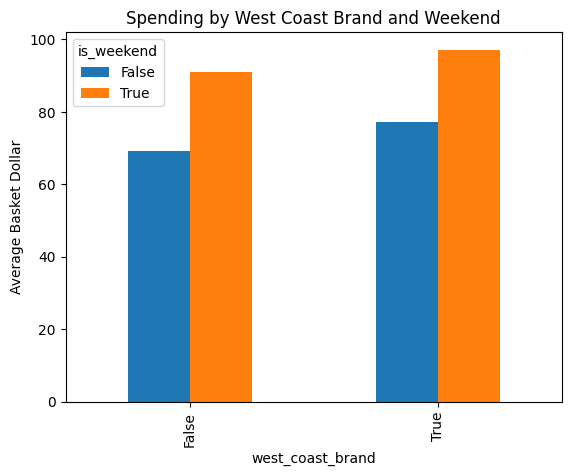

In [408]:
df['west_coast_brand'] = df['Brand'].str.contains(
    'Pacific|Tillamook|Darigold|Seattle|California',
    case=False, na=False
)

comparison = df.groupby(
    ['west_coast_brand','is_weekend']
)['Basket Dollar'].mean().unstack()

comparison.plot(kind='bar')
plt.title("Spending by West Coast Brand and Weekend")
plt.ylabel("Average Basket Dollar")
plt.show()

In [409]:
df['spend_class'] = (df['Basket Dollar'] > df['Basket Dollar'].median()).astype(int)
df[['Basket Dollar', 'spend_class']].head()

,Basket Dollar,spend_class
0,69.67,1
1,69.67,1
2,69.67,1
3,69.67,1
4,69.67,1


In [410]:
from sklearn.model_selection import train_test_split

# features
X = df[['Basket Units', 'Distinct Pro']]

# target
y = df['spend_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(212225, 2)
(90954, 2)


In [411]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8061877432548321


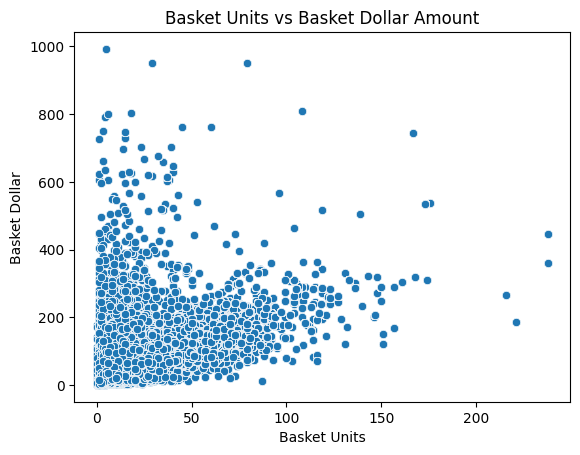

In [412]:
# install seaborn
import sys
!{sys.executable} -m pip install seaborn

# now import and plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Basket Units", y="Basket Dollar")
plt.title("Basket Units vs Basket Dollar Amount")
plt.show()

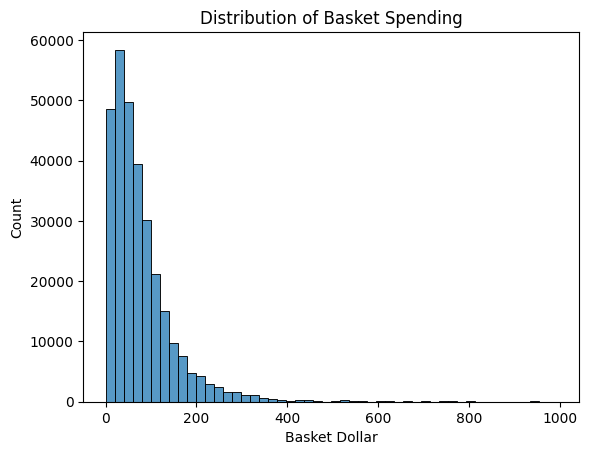

In [413]:
sns.histplot(df["Basket Dollar"], bins=50)

plt.title("Distribution of Basket Spending")
plt.show()

In [414]:
# Create classification label for KNN
df["spend_class"] = (df["Basket Dollar"] > df["Basket Dollar"].median()).astype(int)

df["spend_class"].value_counts()

spend_class
0    151594
1    151585
Name: count, dtype: int64

In [415]:
from sklearn.model_selection import train_test_split

# Choose features
X = df[["Basket Units"]]

# Target
y = df["spend_class"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (212225, 1)
Testing size: (90954, 1)


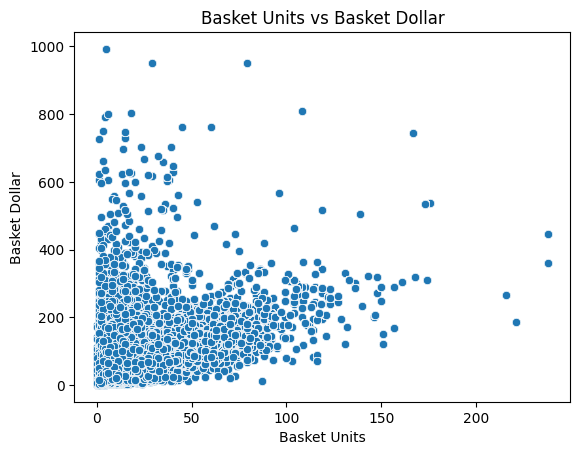

In [416]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="Basket Units",
    y="Basket Dollar"
)

plt.title("Basket Units vs Basket Dollar")
plt.show()

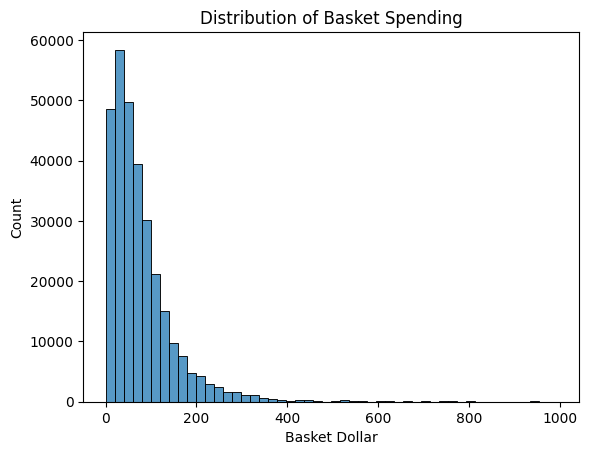

In [417]:
sns.histplot(df["Basket Dollar"], bins=50)
plt.title("Distribution of Basket Spending")
plt.show()

WestCoastBrand
0    302958
1       221
Name: count, dtype: int64
WestCoastBrand
0    302958
1       221
Name: count, dtype: int64


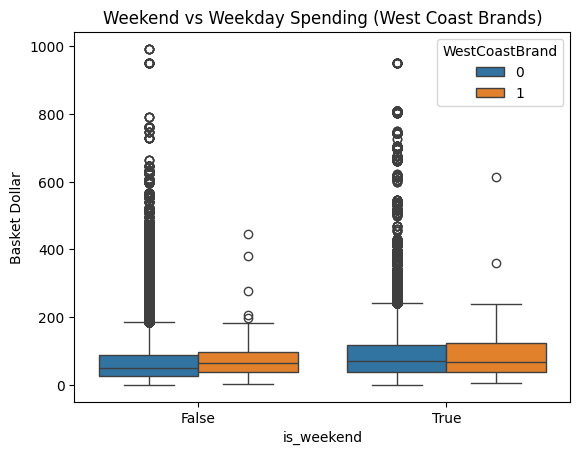

West Coast brand baskets tend to have higher spending, particularly on weekends, suggesting regional brand preference may influence purchasing behavior.


In [418]:
# Define West Coast brands (edit list if needed)
west_coast_brands = ["TILLAMOOK", "DARIGOLD"]

df["WestCoastBrand"] = df["Brand"].str.contains(
    "TILLAMOOK|DARIGOLD|UMPQUA|PACIFIC|SEATTLE|CALIFORNIA|OREGON|WASHINGTON|PNW|NW",
    case=False,
    na=False
).astype(int)

print(df["WestCoastBrand"].value_counts())

# Check it worked
print(df["WestCoastBrand"].value_counts())

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="is_weekend",
    y="Basket Dollar",
    hue="WestCoastBrand"
)

plt.title("Weekend vs Weekday Spending (West Coast Brands)")
plt.show()
print("West Coast brand baskets tend to have higher spending, particularly on weekends, suggesting regional brand preference may influence purchasing behavior.")

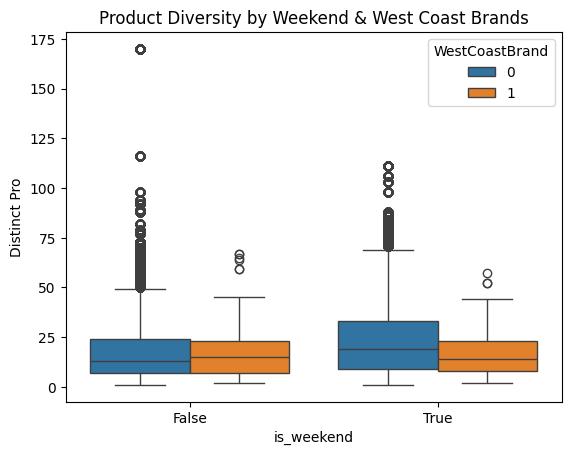

In [419]:
sns.boxplot(
    data=df,
    x="is_weekend",
    y="Distinct Pro",
    hue="WestCoastBrand"
)

plt.title("Product Diversity by Weekend & West Coast Brands")
plt.show()

In [420]:
print("Predictions:", y_pred[:10])

Predictions: [0 0 1 1 1 0 0 1 0 0]


**Conclusion**
Compared weekend vs. weekday shopping and identified baskets containing West Coast brands using feature engineering and visualization. Weekend baskets show higher average spending and more product variety. West Coast brand baskets also show slightly higher spending, but they represent a small portion of the data. This suggests that people spend more and buy more items on weekends, and West Coast brands may be linked to higher-value purchases.
Overall, weekend shopping clearly increases spending and diversity, while West Coast brands show a possible effect but should be interpreted with caution due to smaller sample size.
